# USGS Earthquake Agent Streaming Demo

This notebook demonstrates the dedicated `usgs_earthquake_agent` using GAS streaming mode. It walks through every public skill advertised by the agent:

- Retrieve and export earthquake events
- Map earthquake activity
- Summarize earthquake activity
- Analyze earthquake patterns
- Generate alert-ready summaries
- Generate earthquake reports

The agent does not require a USGS API key. If you provide an OpenAI or GIBD key, the service may use LLM-assisted planning for vague requests; otherwise it uses deterministic request parsing and deterministic USGS/geospatial tools.

## Install and Import

In [1]:
%pip install -q gas-client requests pandas geopandas matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from urllib.parse import urljoin, urlparse
import base64
import json
import os

import requests
from dotenv import load_dotenv
from IPython.display import HTML, Image, Markdown, display

from gas_client import GasClient

## User Settings

Use your local server during development or switch `server_url` to the deployed GAS server. Model credentials are optional for this agent.

In [3]:
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "http://127.0.0.1:4042"
# server_url = "https://www.geospatial-agentic-services.online"

openai_api_key = os.getenv("OPENAI_API_KEY")
gibd_api_key = os.getenv("GIBD_API_KEY")

credentials = {}
if openai_api_key:
    credentials["OPENAI_API_KEY"] = openai_api_key

task_credentials = credentials or None
timeout_seconds = 1800

client = GasClient(server_url, artifact_delivery="URL", default_credentials=credentials)
earthquake_agent = client.agent("usgs_earthquake_agent")


## 1. Retrieve And Export Earthquake Events

This demonstrates `retrieve_and_export_earthquake_events`: the agent queries USGS and returns a reusable earthquake event dataset artifact. Here we explicitly request CSV so the export behavior is visible.

In [4]:
retrieve_export_result = earthquake_agent.run_streaming_task(
    "Retrieve M2.5+ earthquakes in California during the past 30 days and export the event dataset as CSV.",
)

[20:55:51] stream_connected: Streaming connection established.
[20:55:52] USGS Earthquake Agent: I received your request.
[20:55:52] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:55:52] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[20:55:52] task_accepted: Task accepted. Starting streaming execution.
[20:55:52] USGS Earthquake Agent: Next I will start the workflow with the prepared inputs.
[20:55:52] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[20:55:55] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[20:55:56] USGS Earthquake Agent: USGS returned 159 earthquake event(s).
[20:55:56] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[20:55:56] USGS Earthquake Agent: The agent finished its workf

In [5]:

client.print_artifacts(retrieve_export_result)
client.display_artifacts(retrieve_export_result)

Artifacts: 1
1. Output
   role             : output_files
   format           : csv
   type             : downloadable_file
   name             : usgs_earthquake_agent-7703-raml-7791.csv
   original_filename: earthquakes_retrieve_m2_5_earthquakes_587566.csv
   size_bytes       : 49904
   url              : http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-7703-raml-7791.csv


event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code
nn00919606,2026-06-03T00:04:38.933000+00:00,1780446250257,"17 km SE of Silver Springs, Nevada",2.76,8.9154,-119.0807,39.3053,117,1.0,,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/nn00919606,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nn00919606&format=geojson,nn,00919606
nc75369806,2026-06-02T16:44:19.020000+00:00,1780439919831,"7 km ESE of Cloverdale, CA",3.71,5.49,-122.937,38.7863333333333,240,75.0,,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369806,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369806&format=geojson,nc,75369806
nc75369706,2026-06-02T13:48:00.420000+00:00,1780410442268,"0 km SSE of Huron, CA",2.64,7.92999982833862,-120.099998474121,36.1990013122559,107,,,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369706,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369706&format=geojson,nc,75369706
ci41478304,2026-06-01T23:41:09.560000+00:00,1780424078053,"17 km WSW of Johannesburg, CA",2.66,7.9,-117.812166666667,35.3111666666667,109,,,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478304,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478304&format=geojson,ci,41478304
ci41478208,2026-06-01T22:56:22.890000+00:00,1780410741105,"17 km WSW of Johannesburg, CA",2.79,7.24,-117.804833333333,35.3051666666667,120,,,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478208,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478208&format=geojson,ci,41478208


## 2. Map Earthquake Activity

This demonstrates `map_earthquake_activity`: the agent creates static PNG and interactive HTML basemap maps, plus an animation-ready GeoJSON artifact with timestamp/style fields.

[20:56:44] stream_connected: Streaming connection established.
[20:56:44] USGS Earthquake Agent: I received your request.
[20:56:44] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:56:44] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[20:56:44] task_accepted: Task accepted. Starting streaming execution.
[20:56:44] USGS Earthquake Agent: Next I will start the workflow with the prepared inputs.
[20:56:44] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[20:56:47] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[20:56:48] USGS Earthquake Agent: USGS returned 135 earthquake event(s).
[20:56:49] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[20:56:49] USGS Earthquake Agent: The agent finished its workf

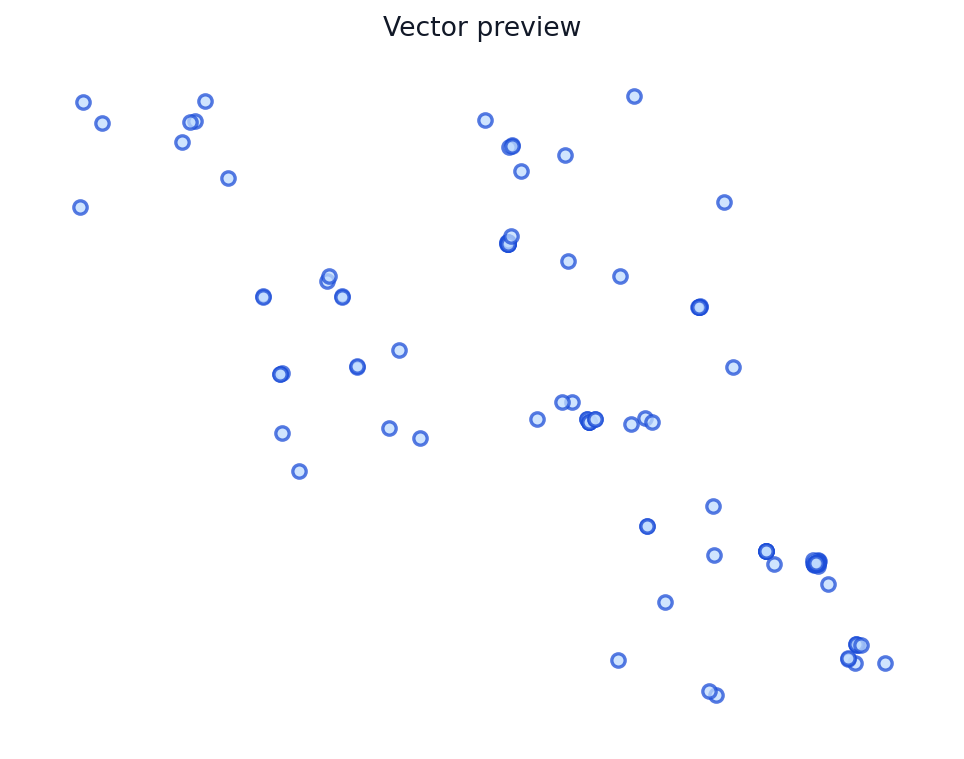

event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code
nc75369706,2026-06-02 13:48:00.420000+00:00,1780410442268,"0 km SSE of Huron, CA",2.64,7.92999982833862,-120.099998474121,36.1990013122559,107,nan,nan,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369706,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369706&format=geojson,nc,75369706
ci41478304,2026-06-01 23:41:09.560000+00:00,1780424078053,"17 km WSW of Johannesburg, CA",2.66,7.9,-117.812166666667,35.3111666666667,109,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478304,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478304&format=geojson,ci,41478304
ci41478208,2026-06-01 22:56:22.890000+00:00,1780410741105,"17 km WSW of Johannesburg, CA",2.79,7.24,-117.804833333333,35.3051666666667,120,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478208,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478208&format=geojson,ci,41478208
ci41478192,2026-06-01 22:34:01.120000+00:00,1780440750618,"18 km WSW of Johannesburg, CA",4.05890859090661,7.64,-117.809833333333,35.299,269,40.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478192,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478192&format=geojson,ci,41478192
ci41476840,2026-05-30 01:55:48.160000+00:00,1780238543785,"18 km WSW of Johannesburg, CA",3.17,7.38,-117.806666666667,35.3,155,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41476840,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41476840&format=geojson,ci,41476840


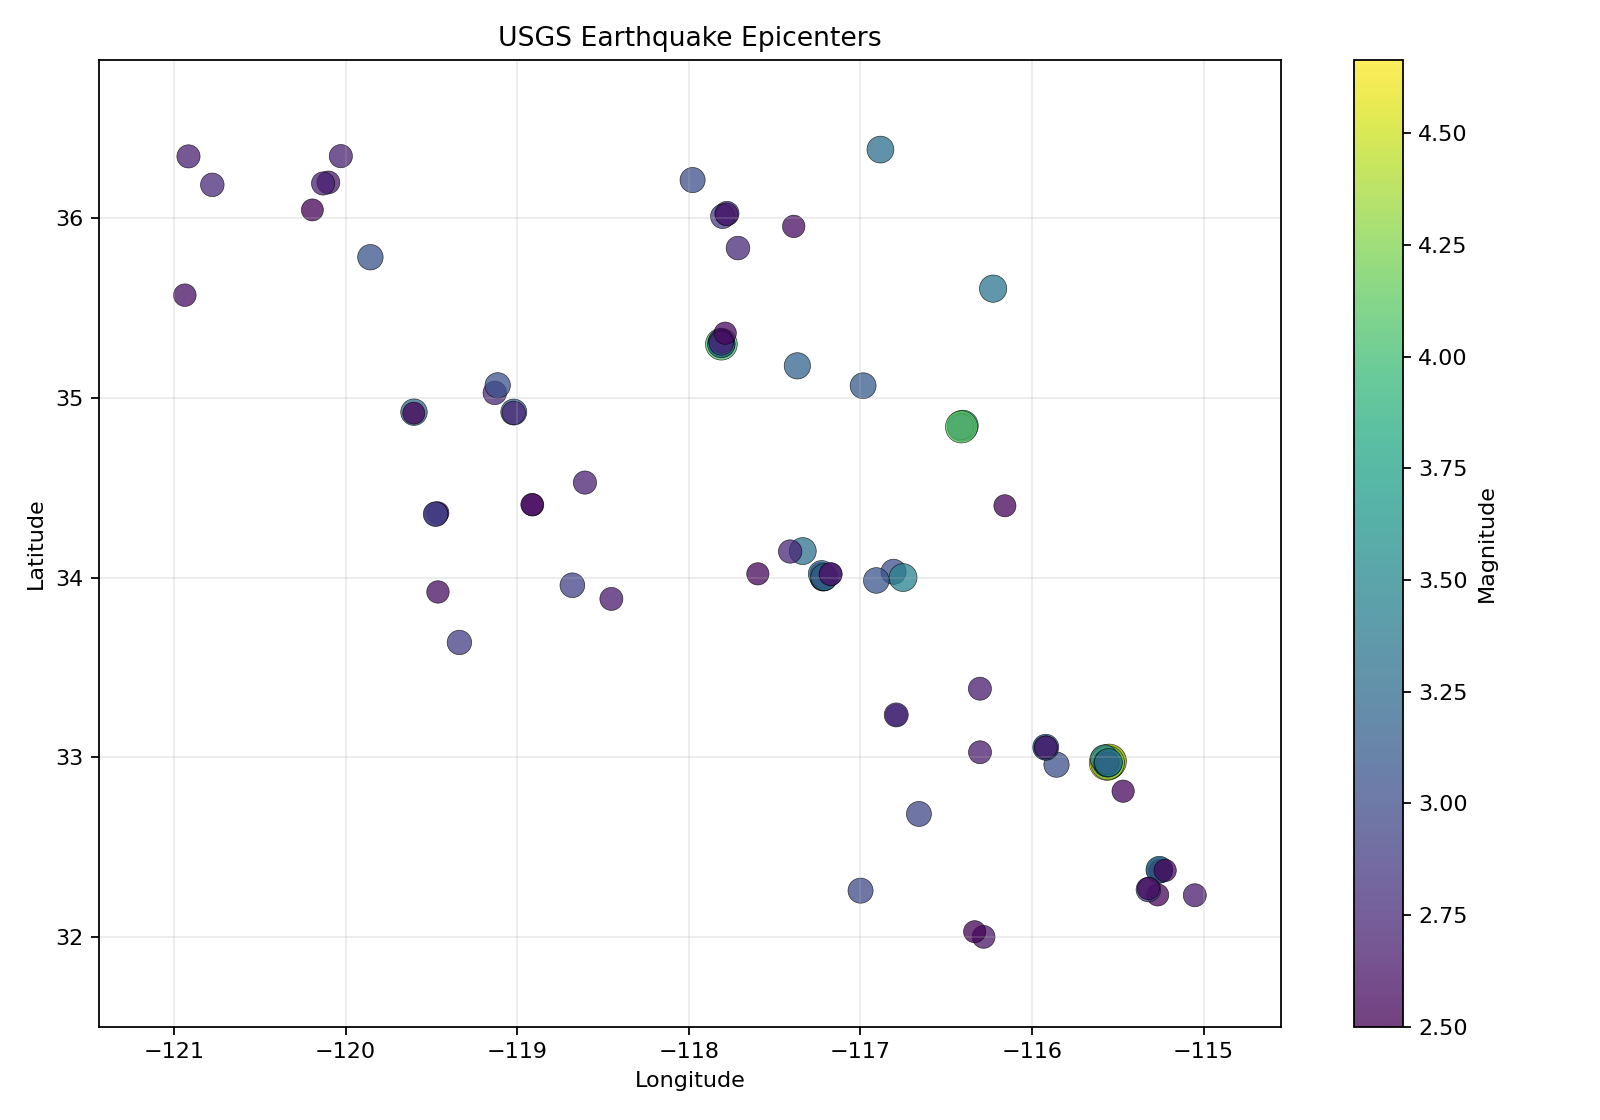

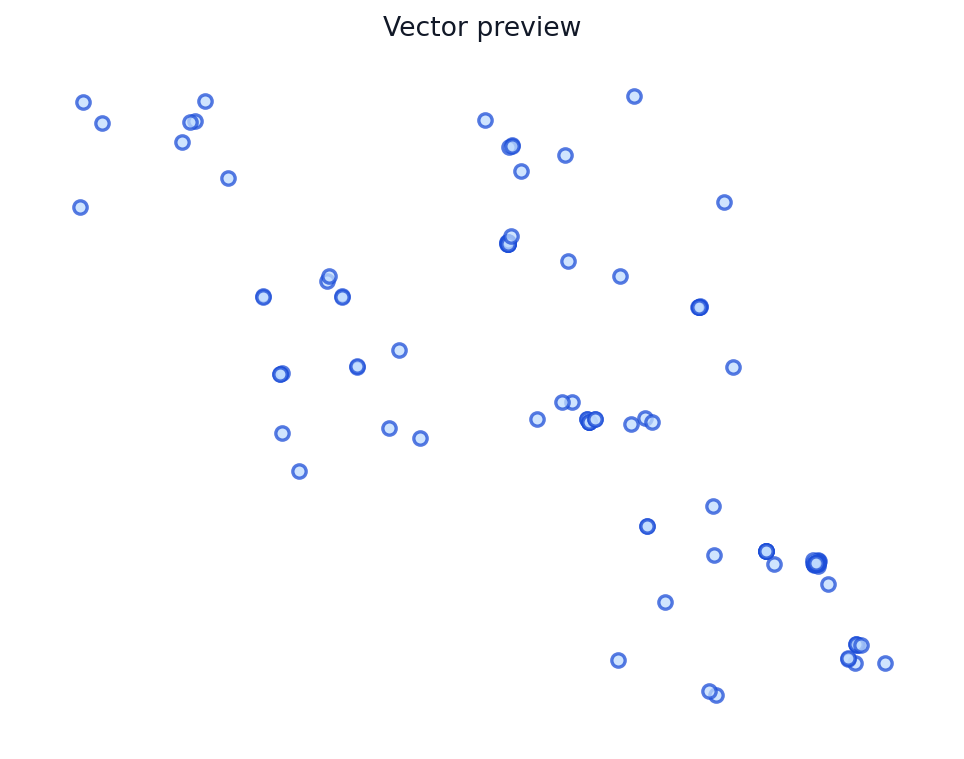

event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code,times,style_radius,style_color
nc75369706,2026-06-02 13:48:00.420000+00:00,1780410442268,"0 km SSE of Huron, CA",2.64,7.92999982833862,-120.099998474121,36.1990013122559,107,nan,nan,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369706,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369706&format=geojson,nc,75369706,2026-06-02 13:48:00.420000+00:00,9.28,#d7191c
ci41478304,2026-06-01 23:41:09.560000+00:00,1780424078053,"17 km WSW of Johannesburg, CA",2.66,7.9,-117.812166666667,35.3111666666667,109,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478304,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478304&format=geojson,ci,41478304,2026-06-01 23:41:09.560000+00:00,9.32,#d7191c
ci41478208,2026-06-01 22:56:22.890000+00:00,1780410741105,"17 km WSW of Johannesburg, CA",2.79,7.24,-117.804833333333,35.3051666666667,120,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478208,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478208&format=geojson,ci,41478208,2026-06-01 22:56:22.890000+00:00,9.58,#d7191c
ci41478192,2026-06-01 22:34:01.120000+00:00,1780440750618,"18 km WSW of Johannesburg, CA",4.05890859090661,7.64,-117.809833333333,35.299,269,40.0,green,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478192,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478192&format=geojson,ci,41478192,2026-06-01 22:34:01.120000+00:00,12.11781718181322,#d7191c
ci41476840,2026-05-30 01:55:48.160000+00:00,1780238543785,"18 km WSW of Johannesburg, CA",3.17,7.38,-117.806666666667,35.3,155,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41476840,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41476840&format=geojson,ci,41476840,2026-05-30 01:55:48.160000+00:00,10.34,#d7191c


In [6]:
map_result = earthquake_agent.run_streaming_task(
    "Map M2.5+ earthquakes in Southern California during the past 90 days. Create a depth-colored map with a basemap and time-animation-ready GeoJSON.",
)

client.display_artifacts(map_result)

In [7]:
client.print_artifacts(map_result)

Artifacts: 4
1. Output
   role             : output_files
   format           : geojson
   type             : downloadable_file
   name             : usgs_earthquake_agent-0029-qpct-7165.geojson
   original_filename: earthquakes_map_m2_5_earthquakes_890678.geojson
   size_bytes       : 87921
   url              : http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-0029-qpct-7165.geojson
2. Output
   role             : output_files
   format           : png
   type             : downloadable_file
   name             : usgs_earthquake_agent-6442-siaz-6136.png
   original_filename: earthquake_map_map_m2_5_earthquakes_173736.png
   size_bytes       : 94816
   url              : http://127.0.0.1:4042/agents/usgs_earthquake_agent/data/usgs_earthquake_agent-6442-siaz-6136.png
3. Output
   role             : output_files
   format           : html
   type             : downloadable_file
   name             : usgs_earthquake_agent-1273-nbmp-8526.html
   original_filena

## 3. Summarize Earthquake Activity

This demonstrates `summarize_earthquake_activity`: the agent computes event counts, top events, magnitude/depth summaries, and a grid summary layer.

[20:57:54] stream_connected: Streaming connection established.
[20:57:54] USGS Earthquake Agent: I received your request.
[20:57:54] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:57:54] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[20:57:54] task_accepted: Task accepted. Starting streaming execution.
[20:57:54] USGS Earthquake Agent: Next I will start the workflow with the prepared inputs.
[20:57:55] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[20:57:58] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[20:57:59] USGS Earthquake Agent: USGS returned 1511 earthquake event(s).
[20:57:59] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[20:57:59] USGS Earthquake Agent: The agent finished its work

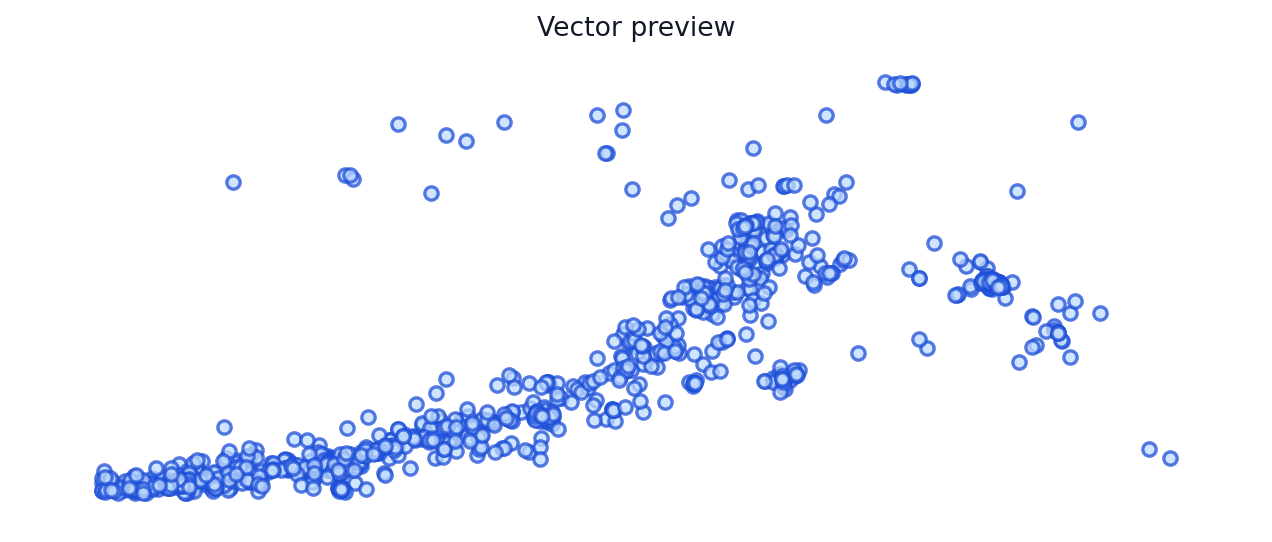

event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code
us7000sq5j,2026-06-02 22:22:45.765000+00:00,1780446426040,"98 km ESE of Akutan, Alaska",3.4,32.917,-164.3699,53.8175,178,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/us7000sq5j,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000sq5j&format=geojson,us,7000sq5j
aka2026kwlwxf,2026-06-02 22:15:51.002000+00:00,1780439119040,"84 km W of Lake Minchumina, Alaska",3.6,1.3,-154.012,64.014,199,nan,nan,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwlwxf,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=aka2026kwlwxf&format=geojson,ak,a2026kwlwxf
aka2026kwekhk,2026-06-02 18:31:42.256000+00:00,1780438396452,"91 km SE of Akutan, Alaska",3.4,32.2,-164.754,53.577,178,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwekhk,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=aka2026kwekhk&format=geojson,ak,a2026kwekhk
aka2026kwdcwi,2026-06-02 17:53:08.180000+00:00,1780437814995,"53 km WNW of Nanwalek, Alaska",3.1,90.4,-152.74,59.593,148,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwdcwi,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=aka2026kwdcwi&format=geojson,ak,a2026kwdcwi
us7000sq3i,2026-06-02 17:01:49.036000+00:00,1780430325315,"76 km SSE of Sand Point, Alaska",3.5,35.0,-160.0924,54.6873,188,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/us7000sq3i,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000sq3i&format=geojson,us,7000sq3i


event_id,time,place,mag,depth_km,latitude,longitude,sig,felt,alert,tsunami,url
us7000sq5j,2026-06-02T22:22:45.765000+00:00,"98 km ESE of Akutan, Alaska",3.4,32.917,53.8175,-164.3699,178,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/us7000sq5j
aka2026kwlwxf,2026-06-02T22:15:51.002000+00:00,"84 km W of Lake Minchumina, Alaska",3.6,1.3,64.014,-154.012,199,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwlwxf
aka2026kwekhk,2026-06-02T18:31:42.256000+00:00,"91 km SE of Akutan, Alaska",3.4,32.2,53.577,-164.754,178,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwekhk
aka2026kwdcwi,2026-06-02T17:53:08.180000+00:00,"53 km WNW of Nanwalek, Alaska",3.1,90.4,59.593,-152.74,148,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/aka2026kwdcwi
us7000sq3i,2026-06-02T17:01:49.036000+00:00,"76 km SSE of Sand Point, Alaska",3.5,35.0,54.6873,-160.0924,188,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/us7000sq3i


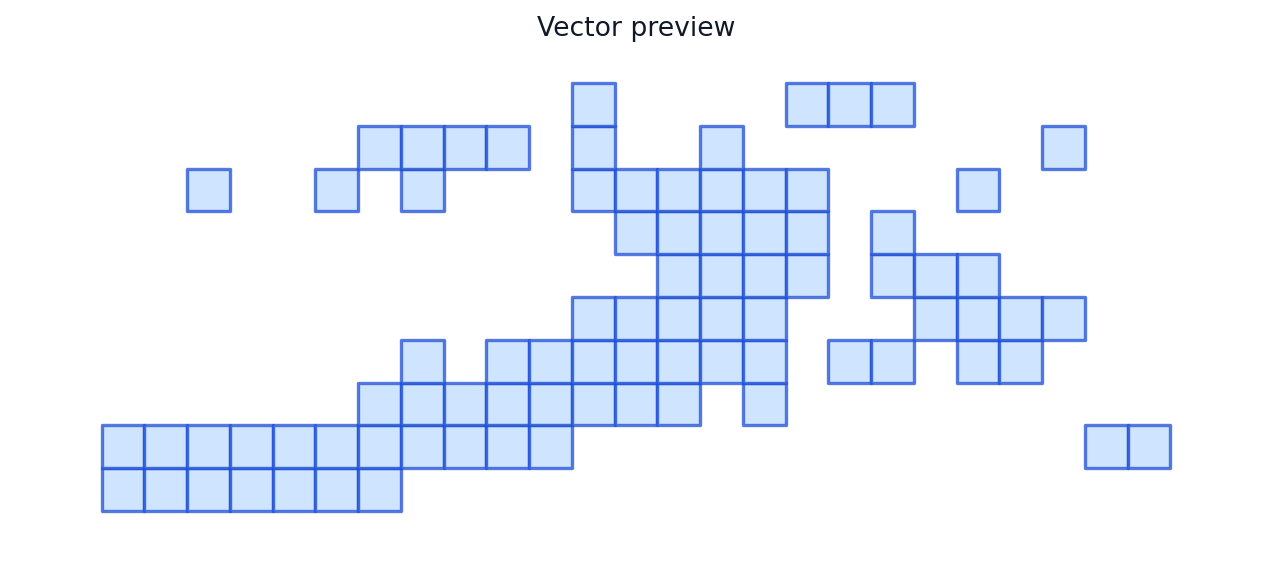

grid_id,event_count,max_magnitude,mean_depth_km
-180.0_50.0,48,5.0,41.540708333333335
-178.0_50.0,66,5.3,43.33563636363636
-176.0_50.0,51,5.2,40.42370588235294
-174.0_50.0,22,4.1,34.498
-172.0_50.0,11,5.3,15.33290909090909


In [8]:
summary_result = earthquake_agent.run_streaming_task(
    "Summarize M3+ earthquake activity in Alaska during the past 180 days. Include top events, magnitude and depth summaries, and a grid summary layer.",
    parameters={"output_format": "geojson", "grid_degrees": 2.0},
)

client.display_artifacts(summary_result)

## 4. Analyze Earthquake Patterns

This demonstrates `analyze_earthquake_patterns`: the agent creates impact buffers and performs simple cluster screening. These are screening artifacts for geospatial workflows, not formal seismic hazard products.

[20:58:29] stream_connected: Streaming connection established.
[20:58:29] USGS Earthquake Agent: I received your request.
[20:58:29] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:58:29] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[20:58:29] task_accepted: Task accepted. Starting streaming execution.
[20:58:30] USGS Earthquake Agent: Next I will start the workflow with the prepared inputs.
[20:58:30] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[20:58:32] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[20:58:33] USGS Earthquake Agent: USGS returned 1167 earthquake event(s).
[20:58:34] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[20:58:34] USGS Earthquake Agent: The agent finished its work

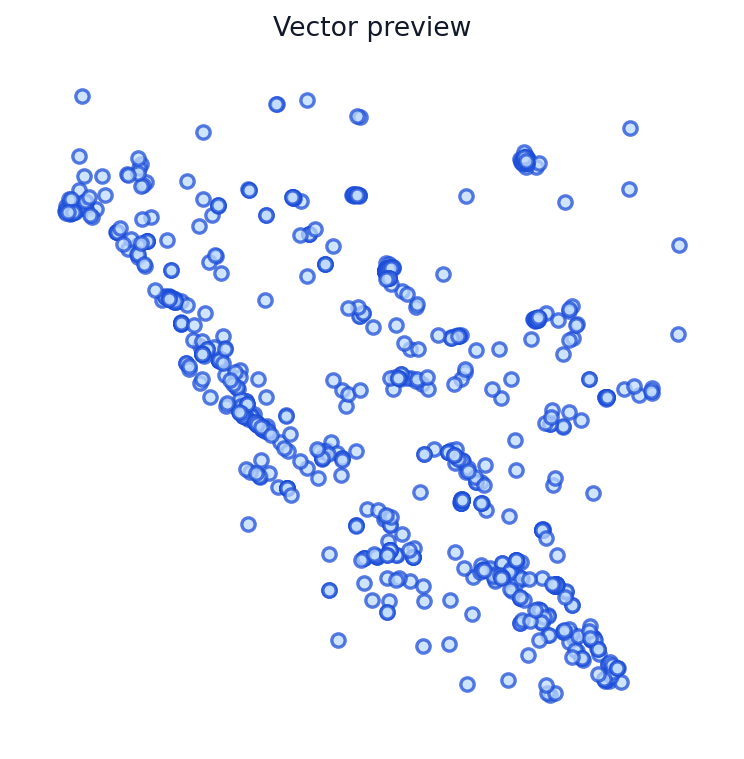

event_id,time,updated,place,mag,depth_km,longitude,latitude,sig,felt,alert,tsunami,type,status,url,detail,net,code
nn00919606,2026-06-03 00:04:38.933000+00:00,1780446250257,"17 km SE of Silver Springs, Nevada",2.76,8.9154,-119.0807,39.3053,117,1.0,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/nn00919606,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nn00919606&format=geojson,nn,00919606
nc75369806,2026-06-02 16:44:19.020000+00:00,1780439919831,"7 km ESE of Cloverdale, CA",3.71,5.49,-122.937,38.7863333333333,240,75.0,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369806,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369806&format=geojson,nc,75369806
nc75369706,2026-06-02 13:48:00.420000+00:00,1780410442268,"0 km SSE of Huron, CA",2.64,7.92999982833862,-120.099998474121,36.1990013122559,107,nan,nan,0,earthquake,automatic,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369706,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75369706&format=geojson,nc,75369706
ci41478304,2026-06-01 23:41:09.560000+00:00,1780424078053,"17 km WSW of Johannesburg, CA",2.66,7.9,-117.812166666667,35.3111666666667,109,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478304,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478304&format=geojson,ci,41478304
ci41478208,2026-06-01 22:56:22.890000+00:00,1780410741105,"17 km WSW of Johannesburg, CA",2.79,7.24,-117.804833333333,35.3051666666667,120,nan,nan,0,earthquake,reviewed,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478208,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ci41478208&format=geojson,ci,41478208


event_id,time,place,mag,depth_km,latitude,longitude,sig,felt,alert,tsunami,url
nn00919606,2026-06-03T00:04:38.933000+00:00,"17 km SE of Silver Springs, Nevada",2.76,8.9154,39.3053,-119.0807,117,1.0,,0,https://earthquake.usgs.gov/earthquakes/eventpage/nn00919606
nc75369806,2026-06-02T16:44:19.020000+00:00,"7 km ESE of Cloverdale, CA",3.71,5.49,38.7863333333333,-122.937,240,75.0,,0,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369806
nc75369706,2026-06-02T13:48:00.420000+00:00,"0 km SSE of Huron, CA",2.64,7.92999982833862,36.1990013122559,-120.099998474121,107,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/nc75369706
ci41478304,2026-06-01T23:41:09.560000+00:00,"17 km WSW of Johannesburg, CA",2.66,7.9,35.3111666666667,-117.812166666667,109,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478304
ci41478208,2026-06-01T22:56:22.890000+00:00,"17 km WSW of Johannesburg, CA",2.79,7.24,35.3051666666667,-117.804833333333,120,,,0,https://earthquake.usgs.gov/earthquakes/eventpage/ci41478208


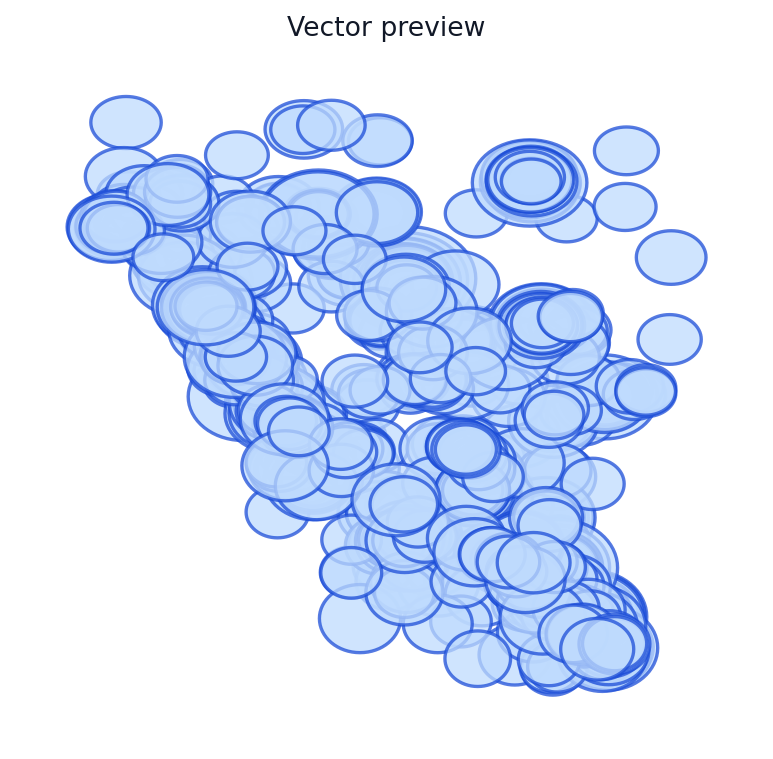

event_id,mag,buffer_km
nn00919606,2.76,69.0
nc75369806,3.71,92.75
nc75369706,2.64,66.0
ci41478304,2.66,66.5
ci41478208,2.79,69.75


In [9]:
pattern_result = earthquake_agent.run_streaming_task(
    "Analyze M2.5+ earthquake patterns in California during the past 300 days. Create impact buffers and screen for clusters.",
    parameters={"output_format": "geojson", "buffer_km": 50},
)

client.display_artifacts(pattern_result)

## 6. Generate Earthquake Report

This demonstrates `generate_earthquake_report`: the agent returns Markdown and HTML reports with maps, charts, event tables, methods/provenance, and limitations.

In [13]:
report_result = earthquake_agent.run_streaming_task(
    "Generate an HTML earthquake activity report for M4.5+ earthquakes near Japan during the past 300 days. Include maps, charts, top events, methods, provenance, and limitations.",
)



[21:00:46] stream_connected: Streaming connection established.
[21:00:46] USGS Earthquake Agent: I received your request.
[21:00:46] USGS Earthquake Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[21:00:46] USGS Earthquake Agent: I found the required credentials and can start the model-backed workflow.
[21:00:47] task_accepted: Task accepted. Starting streaming execution.
[21:00:47] USGS Earthquake Agent: Next I will start the workflow with the prepared inputs.
[21:00:47] USGS Earthquake Agent: I am interpreting the earthquake request and choosing USGS query and output tools.
[21:00:51] USGS Earthquake Agent: I am retrieving earthquake events from USGS.
[21:00:52] USGS Earthquake Agent: USGS returned 527 earthquake event(s).
[21:00:53] USGS Earthquake Agent: I am packaging earthquake datasets, maps, reports, provenance, and limitations.
[21:00:53] USGS Earthquake Agent: The agent finished its workf

In [ ]:
client.display_artifacts(report_result, format="html")